# Refinery production and shadow pricing
[![refinery-production.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/marcos-dv/educational/refinery-production.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/marcos-dv/educational/refinery-production.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/marcos-dv/educational/refinery-production.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/marcos-dv/educational/refinery-production.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/marcos-dv/educational/refinery-production.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/marcos-dv/educational/refinery-production.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/marcos-dv/educational/refinery-production.ipynb)](https://ampl.com)

Description: This is a simple linear optimization problem in six variables, but with four equality constraints it allows for a graphical explanation of some unusually large shadow prices for manufacturing capacity. See other examples at [MO-BOOK: Hands-On Mathematical Optimization with AMPL in Python](https://ampl.com/mo-book/).

Tags: amplpy, cbc, finance, refinery, dual-values, shadow-prices

Notebook author: Marcos Dominguez <<marcos@ampl.com>>

In [1]:
# Install dependencies
%pip install -q amplpy pandas numpy matplotlib
import pandas as pd
import numpy as np

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["coin"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

This example derived from Example 19.3 from Seborg, Edgar, Mellichamp, and Doyle.

> Seborg, Dale E., Thomas F. Edgar, Duncan A. Mellichamp, and Francis J. Doyle III. Process dynamics and control. John Wiley & Sons, 2016.

The changes include updating prices, new solutions using optimization modeling languages, adding constraints, and adjusting parameter values to demonstrate the significance of duals and their interpretation as shadow prices.

This is one of the multiple case studies presented in the [MO-BOOK: Hands-On Mathematical Optimization with AMPL in Python](https://ampl.com/mo-book/).

## Problem data

In [3]:
import pandas as pd

products = pd.DataFrame(
    {
        "gasoline": {"capacity": 24000, "price": 108},
        "kerosine": {"capacity": 2000, "price": 72},
        "fuel oil": {"capacity": 6000, "price": 63},
        "residual": {"capacity": 2500, "price": 30},
    }
).T

crudes = pd.DataFrame(
    {
        "crude 1": {"available": 28000, "price": 72, "process_cost": 1.5},
        "crude 2": {"available": 15000, "price": 45, "process_cost": 3},
    }
).T

# note: volumetric yields may not add to 100%
yields = pd.DataFrame(
    {
        "crude 1": {"gasoline": 80, "kerosine": 5, "fuel oil": 10, "residual": 5},
        "crude 2": {"gasoline": 44, "kerosine": 10, "fuel oil": 36, "residual": 10},
    }
).T

display(products)
display(crudes)
display(yields)

,capacity,price
gasoline,24000,108
kerosine,2000,72
fuel oil,6000,63
residual,2500,30


,available,price,process_cost
crude 1,28000.0,72.0,1.5
crude 2,15000.0,45.0,3.0


,gasoline,kerosine,fuel oil,residual
crude 1,80,5,10,5
crude 2,44,10,36,10


## AMPL Model

In [4]:
%%writefile refinery.mod

set CRUDES;
set PRODUCTS;

param price {PRODUCTS union CRUDES};   # selling price for products, purchase price for crudes
param process_cost {CRUDES};
param yields {PRODUCTS, CRUDES};       # percent yields (0..100)
param available {CRUDES};
param capacity  {PRODUCTS};

# decision variables
var x {c in CRUDES}   >= 0;            # crude consumption
var y {p in PRODUCTS} >= 0;            # product production

# objective
maximize profit:
    sum {p in PRODUCTS} price[p] * y[p]
  - sum {c in CRUDES}   price[c] * x[c]
  - sum {c in CRUDES}   process_cost[c] * x[c];

# constraints
subject to balances {p in PRODUCTS}:
    y[p] = sum {c in CRUDES} yields[p,c] * x[c] / 100;

subject to feed_limit {c in CRUDES}:
    x[c] <= available[c];

subject to cap_limit {p in PRODUCTS}:
    y[p] <= capacity[p];

Overwriting refinery.mod


In [5]:
SOLVER = "cbc"

m = AMPL()

m.read("refinery.mod")

m.set_data(crudes, "CRUDES")
m.set_data(products, "PRODUCTS")
m.param["yields"] = yields.T

# solution
m.solve(solver=SOLVER, verbose=False)
assert m.solve_result == "solved", m.solve_result
print(f"Profit: {m.obj['profit'].value():0.2f}\n")

# -----------------------
# Extract primals
# -----------------------
x = m.var["x"].get_values().to_pandas()
y = m.var["y"].get_values().to_pandas()

# -----------------------
# Extract duals (shadow prices)
# -----------------------
feed_dual = m.con["feed_limit"].get_values("dual").to_pandas()  # column "dual"
cap_dual = m.con["cap_limit"].get_values("dual").to_pandas()
bal_dual = m.con["balances"].get_values("dual").to_pandas()

Profit: 860275.86



## Crude oil feed results

In [6]:
results_crudes = crudes
results_crudes["consumption"] = x.values
results_crudes["shadow price"] = feed_dual

display(results_crudes.round(1))

,available,price,process_cost,consumption,shadow price
crude 1,28000.0,72.0,1.5,26206.9,0
crude 2,15000.0,45.0,3.0,6896.6,0


## Refinery production results

In [7]:
results_products = products
results_products["production"] = y.reindex(results_products.index)
results_products["unused capacity"] = (
    results_products["capacity"] - results_products["production"]
)
results_products["shadow price"] = cap_dual

display(results_products.round(1))

,capacity,price,production,unused capacity,shadow price
gasoline,24000,108,24000.0,0.0,14.0
kerosine,2000,72,2000.0,0.0,262.6
fuel oil,6000,63,5103.4,896.6,0.0
residual,2500,30,2000.0,500.0,0.0


## Why is the shadow price of kerosine so high?

(0.0, 24000.0)

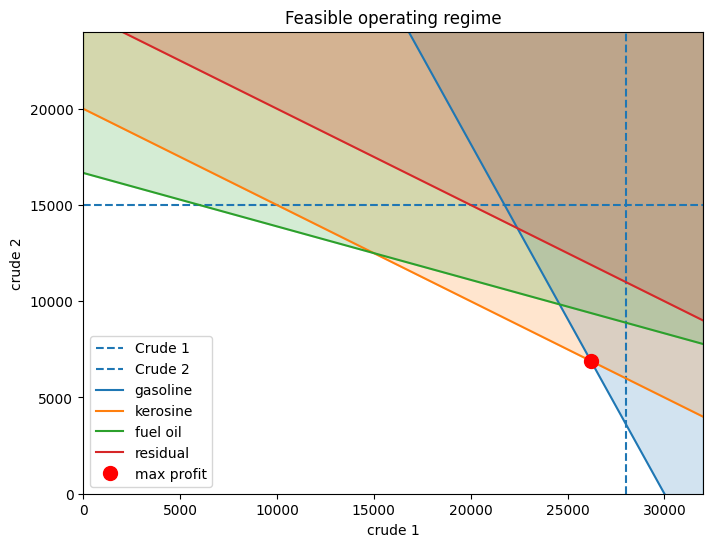

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
ylim = 24000
xlim = 32000

ax.axvline(crudes["available"].iloc[0], linestyle="--", label="Crude 1")
ax.axhline(crudes["available"].iloc[1], linestyle="--", label="Crude 2")

xplot = np.linspace(0, xlim)
for product in products.index:
    b = 100 * products.loc[product, "capacity"] / yields[product].iloc[1]
    m = -yields[product].iloc[0] / yields[product].iloc[1]
    line = ax.plot(xplot, m * xplot + b, label=product)
    ax.fill_between(xplot, m * xplot + b, 30000, color=line[0].get_color(), alpha=0.2)

ax.plot(x.values[0], x.values[1], "ro", ms=10, label="max profit")
ax.set_title("Feasible operating regime")
ax.set_xlabel(crudes.index[0])
ax.set_ylabel(crudes.index[1])
ax.legend()
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)

## Suggested Exercises

1. Suppose the refinery makes a substantial investment to double kerosene production in order to increase profits. What becomes the limiting constraint?

2. How do prices of crude oil and refinery products change the location of the optimum operating point?

3. A refinery is a financial asset for the conversion of commodity crude oils into commodity hydrocarbons. What economic value can be assigned to owning the option to convert crude oils into other commodities?